In [157]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [158]:
pill_path= "/content/drive/MyDrive/Junior Semester 2/Computer Vision/Practicals/Practical 2/pills.png"

In [159]:
import cv2
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

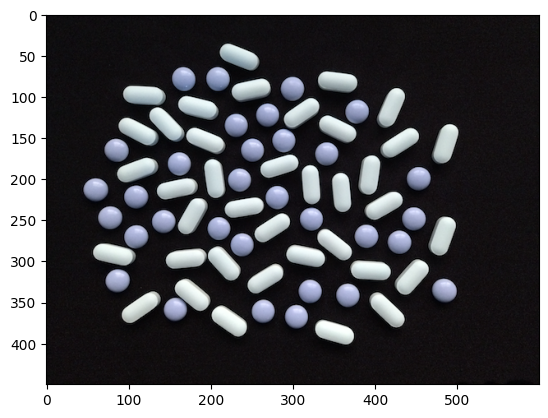

In [160]:
img = cv2.imread(pill_path)
plt.imshow(img)

# Pre Processing

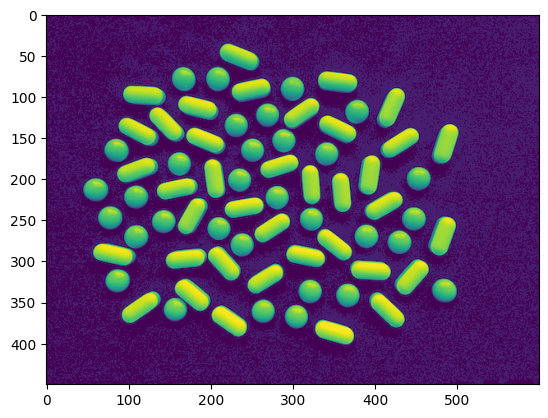

In [161]:
gray = cv2.imread(pill_path,cv2.IMREAD_GRAYSCALE)
plt.imshow(gray)

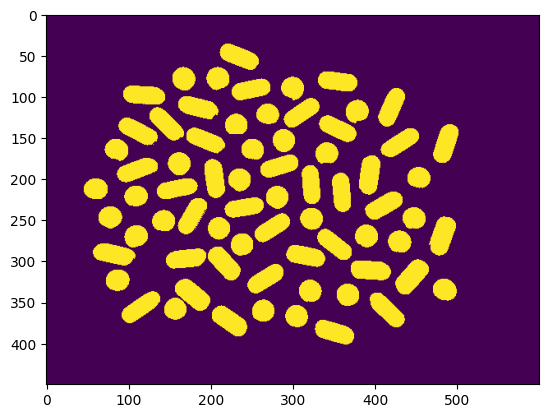

In [162]:
ret1, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(binary)

# Segmentation

In [163]:
labels = measure.label(binary, 2)

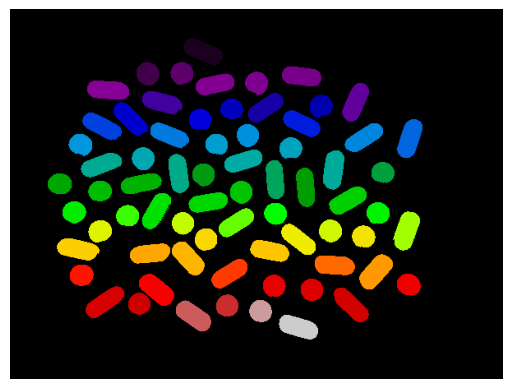

In [164]:
plt.imshow(labels, cmap='nipy_spectral')
plt.axis('off')
plt.show()

# Feature Extraction

In [165]:
features = measure.regionprops(labels)
areas = [region.area for region in features]
print(sorted(areas))

[np.float64(549.0), np.float64(554.0), np.float64(559.0), np.float64(569.0), np.float64(571.0), np.float64(575.0), np.float64(577.0), np.float64(577.0), np.float64(579.0), np.float64(582.0), np.float64(584.0), np.float64(587.0), np.float64(591.0), np.float64(591.0), np.float64(593.0), np.float64(594.0), np.float64(595.0), np.float64(595.0), np.float64(595.0), np.float64(596.0), np.float64(597.0), np.float64(599.0), np.float64(601.0), np.float64(603.0), np.float64(605.0), np.float64(606.0), np.float64(607.0), np.float64(607.0), np.float64(608.0), np.float64(608.0), np.float64(611.0), np.float64(626.0), np.float64(883.0), np.float64(889.0), np.float64(891.0), np.float64(892.0), np.float64(904.0), np.float64(907.0), np.float64(910.0), np.float64(910.0), np.float64(915.0), np.float64(916.0), np.float64(924.0), np.float64(932.0), np.float64(934.0), np.float64(937.0), np.float64(938.0), np.float64(940.0), np.float64(946.0), np.float64(948.0), np.float64(954.0), np.float64(955.0), np.float64(

# Classification
- Had to filter out the area since one of the blobs exceeded the average. I am assuming this was the background because the area of the blob is 214841.0

In [169]:
ratio = []
for region in features:
  if 500 < region.area < 2000 and region.minor_axis_length > 0:
    ratio.append(region.major_axis_length / region.minor_axis_length)

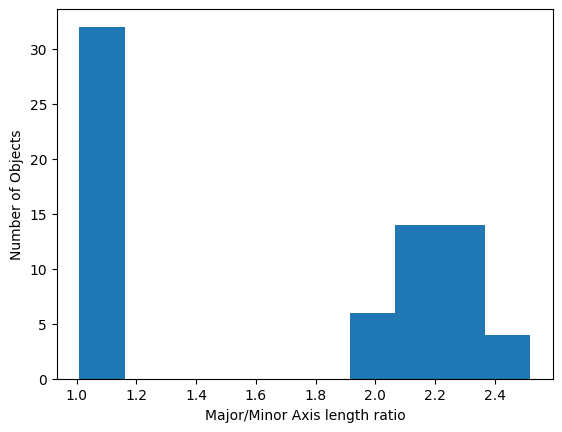

In [170]:
plt.hist(ratio)
plt.ylabel('Number of Objects')
plt.xlabel('Major/Minor Axis length ratio')
plt.show()

In [171]:
ratio_check = 1.5
oval_count = 0
circle_count = 0
for i in ratio:
  if ratio_check > i:
    circle_count += 1
  else:
    oval_count += 1

print(f"{oval_count} oval pills and {circle_count} round pills")

38 oval pills and 32 round pills
